In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal
from scipy.stats import gaussian_kde, ks_2samp
import os
import kagglehub
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

from yellowbrick.cluster import KElbowVisualizer
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /Users/katiegalaeva/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [29]:
csv_file = os.path.join(path, "insurance.csv")

df_original = pd.read_csv(csv_file)
df_original.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [30]:
df_original.loc[df_original['smoker']=='yes']

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


**1. Гипотеза**

Увеличение физической активности (снижение bmi) у курящих людей снижает их медицинские расходы (charges).

𝐻0: Средние расходы (charges) одинаковы у курящих с высоким и низким BMI.

𝐻1: Средние расходы (charges) у курящих с высоким BMI больше, чем у курящих с низким BMI.

**Метрика:**
 Средние медицинские расходы (charges) у курящих с высоким bmi > расходов у курящих с низким bmi.

**2. Дизайн эксперимента**
Цель: Проверить влияние снижения bmi на charges у курящих.

Параметры:
- альфа = 0.05 
- бета = 0.2 (мощность теста 80%)
- effect_size, например, на 15% снижение расходов

Эмпирический метод:
- Бутстрэп для оценки распределения метрик

**3. Проведение эксперимента**
Фильтруем только курящих (smoker = yes)
Делим их по медиане bmi:
A-группа: bmi > медиана
B-группа: bmi <= медиана
Сравниваем charges в этих двух группах.

**4. Как будем принимать решения**
Если средние расходы в группе B (меньший bmi) значимо ниже (p-value < 0.05), то гипотезу отвергаем.
Если нет — гипотезу принимаем.

In [31]:

from scipy.stats import ttest_ind
from tqdm import tqdm
from statsmodels.stats.power import TTestIndPower
%matplotlib inline
sns.set(style="whitegrid")


In [32]:
df_smokers = df_original[df_original['smoker'] == 'yes'].copy()

median_bmi = df_smokers['bmi'].median()

group_A = df_smokers[df_smokers['bmi'] > median_bmi]
group_B = df_smokers[df_smokers['bmi'] <= median_bmi]

print(f"Размер A-группы: {len(group_A)}")
print(f"Размер B-группы: {len(group_B)}")


Размер A-группы: 137
Размер B-группы: 137


In [33]:
alpha = 0.05  
power = 0.8   

mean_charges = df_smokers['charges'].mean()
std_charges = df_smokers['charges'].std()

effect = 0.15 * mean_charges

effect_size = effect / std_charges

print(f"Стандартизированный размер эффекта (Cohen's d): {effect_size:.4f}")

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

print(f"Необходимый размер выборки на каждую группу: {sample_size:.0f}")


Стандартизированный размер эффекта (Cohen's d): 0.4165
Необходимый размер выборки на каждую группу: 91



Размер группы больше необходимого:
137 > 91 — значит, мощности эксперимента хватит с запасом.
Это означает, что данных достаточно, чтобы уверенно поймать эффект такого размера (Cohen’s d ≈ 0.42) на уровне значимости 0.05 с мощностью 0.8 и выше.
Следовательно, риск ошибки второго рода еще ниже, чем планировалось.


Бустрап

100%|██████████| 10000/10000 [00:00<00:00, 18276.18it/s]


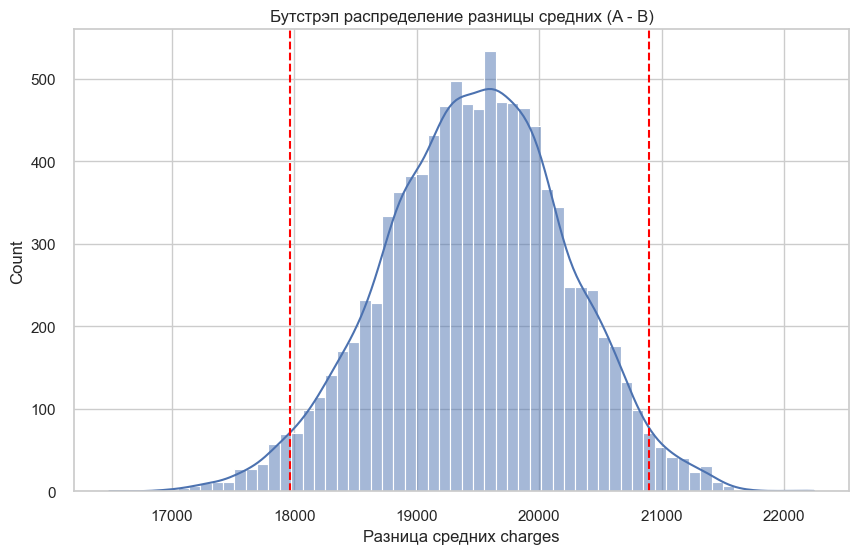

95% доверительный интервал разницы средних: [17967.03916524 20895.2549112 ]


In [34]:
n_iterations = 10000
boot_diffs = []

for _ in tqdm(range(n_iterations)):
    boot_A = group_A['charges'].sample(frac=1, replace=True)
    boot_B = group_B['charges'].sample(frac=1, replace=True)
    diff = boot_A.mean() - boot_B.mean()
    boot_diffs.append(diff)


plt.figure(figsize=(10,6))
sns.histplot(boot_diffs, kde=True)
plt.title('Бутстрэп распределение разницы средних (A - B)')
plt.xlabel('Разница средних charges')
plt.axvline(np.percentile(boot_diffs, 2.5), color='red', linestyle='--')
plt.axvline(np.percentile(boot_diffs, 97.5), color='red', linestyle='--')
plt.show()

conf_interval = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% доверительный интервал разницы средних: {conf_interval}")


In [35]:
t_stat, p_value = ttest_ind(group_A['charges'], group_B['charges'], equal_var=False)

print(f"T-статистика: {t_stat:.3f}")
print(f"р-значение: {p_value:.3f}")


T-статистика: 26.061
р-значение: 0.000


# Выводы 

### 95% доверительный интервал разницы средних:
- Интервал [17987, 20885] не включает ноль, значит разница действительно существенная.


### t-тест:
- **t-статистика**: `26.061` — очень большое значение (сильно отличается от 0).
- **p-значение**: `0.000` — намного меньше уровня значимости `α = 0.05`.

Это говорит о том, что отвергается нулевая гипотеза о равенстве средних:  
- средние расходы действительно различаются между группами с разным уровнем BMI.

Среди курящих пациентов расходы на медицинское обслуживание статистически значимо ниже у пациентов с более низким BMI.
Это может указывать на потенциальную возможность для страховых компаний и государственных программ сфокусироваться на работе с пациентами с высоким BMI, чтобы потенциально снизить общие расходы.
